#Lectura de tonos en un telefono de linea
123
456
789
*0#

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

### Pruebas
Codigos de analisis y grafico de una sola tecla y un solo archivo hechos antes de procesar las 60 mediciones de las 12 teclas a la vez.

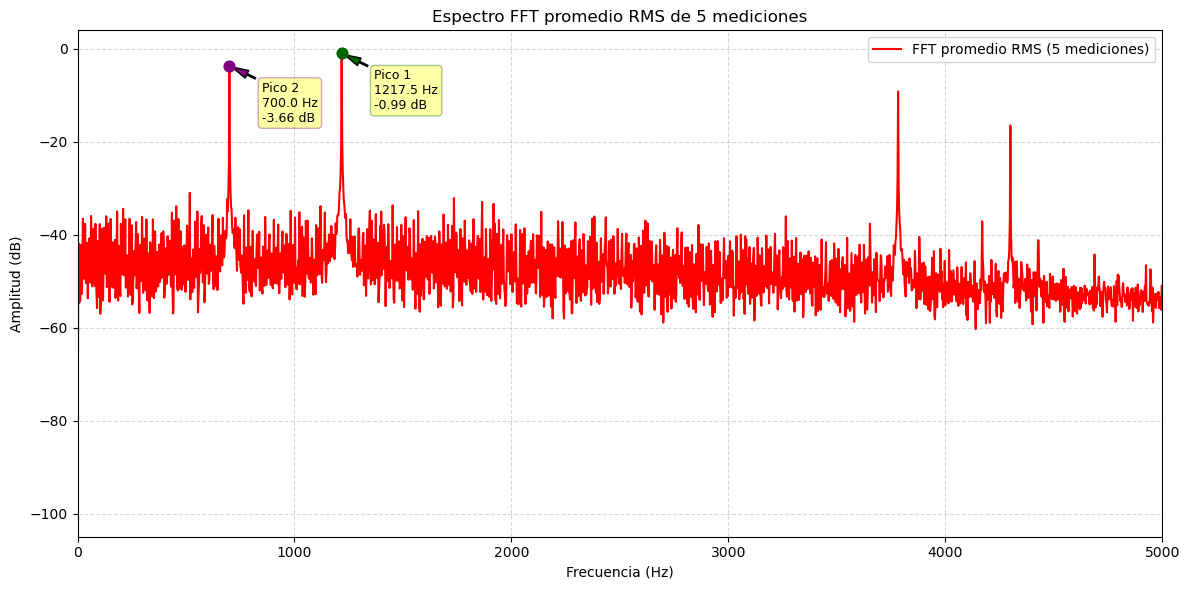

In [2]:
archivos = [
    'medidas/DS0000.CSV',
    'medidas/DS0001.CSV',
    'medidas/DS0002.CSV',
    'medidas/DS0003.CSV',
    'medidas/DS0004.CSV'
]

# ==========================
# Parámetros de muestreo
# ==========================
dt = 1.00000e-04      # 100 µs
N = None

potencias = []

# ==========================
# Procesar cada archivo
# ==========================
for archivo in archivos:

    # Leer archivo
    df = pd.read_csv(
        archivo,
        skiprows=16,
        names=['Tiempo', 'Voltaje'],
        index_col=False
    )

    if N is None:
        N = len(df)

    # Señal
    senal = df['Voltaje'].to_numpy()

    # Eliminar componente continua
    senal = senal - np.mean(senal)

    # FFT
    fft_valores = fft(senal)

    mitad = N // 2

    # Magnitud lineal
    magnitud = (2.0 / N) * np.abs(fft_valores[:mitad])

    # Potencia espectral (amplitud²)
    potencia = magnitud**2

    potencias.append(potencia)

# ==========================
# Promedio RMS
# ==========================
potencia_promedio = np.mean(potencias, axis=0)

# Volver a amplitud
magnitud_promedio = np.sqrt(potencia_promedio)

# Frecuencias
frecuencias = fftfreq(N, dt)
frecuencias_positivas = frecuencias[:mitad]

# Convertir a dB
magnitud_db = 20 * np.log10(np.clip(magnitud_promedio, 1e-5, None))

# ==========================
# Buscar los dos máximos
# ==========================
picos_indices, _ = find_peaks(magnitud_db, distance=10)

picos_ordenados = picos_indices[np.argsort(magnitud_db[picos_indices])][::-1]
top_2_picos = picos_ordenados[:2]

# ==========================
# Graficar
# ==========================
plt.figure(figsize=(12,6))

plt.plot(
    frecuencias_positivas,
    magnitud_db,
    color='red',
    linewidth=1.5,
    label='FFT promedio RMS (5 mediciones)'
)

colores_picos = ['darkgreen', 'purple']

for i, indice_pico in enumerate(top_2_picos):

    freq_pico = frecuencias_positivas[indice_pico]
    amp_db_pico = magnitud_db[indice_pico]

    plt.scatter(
        freq_pico,
        amp_db_pico,
        color=colores_picos[i],
        s=60,
        zorder=5
    )

    texto = f"Pico {i+1}\n{freq_pico:.1f} Hz\n{amp_db_pico:.2f} dB"

    plt.annotate(
        texto,
        xy=(freq_pico, amp_db_pico),
        xytext=(freq_pico + 150, amp_db_pico - 12),
        arrowprops=dict(
            facecolor=colores_picos[i],
            shrink=0.08,
            width=1,
            headwidth=6
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="yellow",
            alpha=0.35,
            ec=colores_picos[i]
        ),
        fontsize=9
    )

plt.title('Espectro FFT promedio RMS de 5 mediciones')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (dB)')
plt.xlim(0, 5000)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

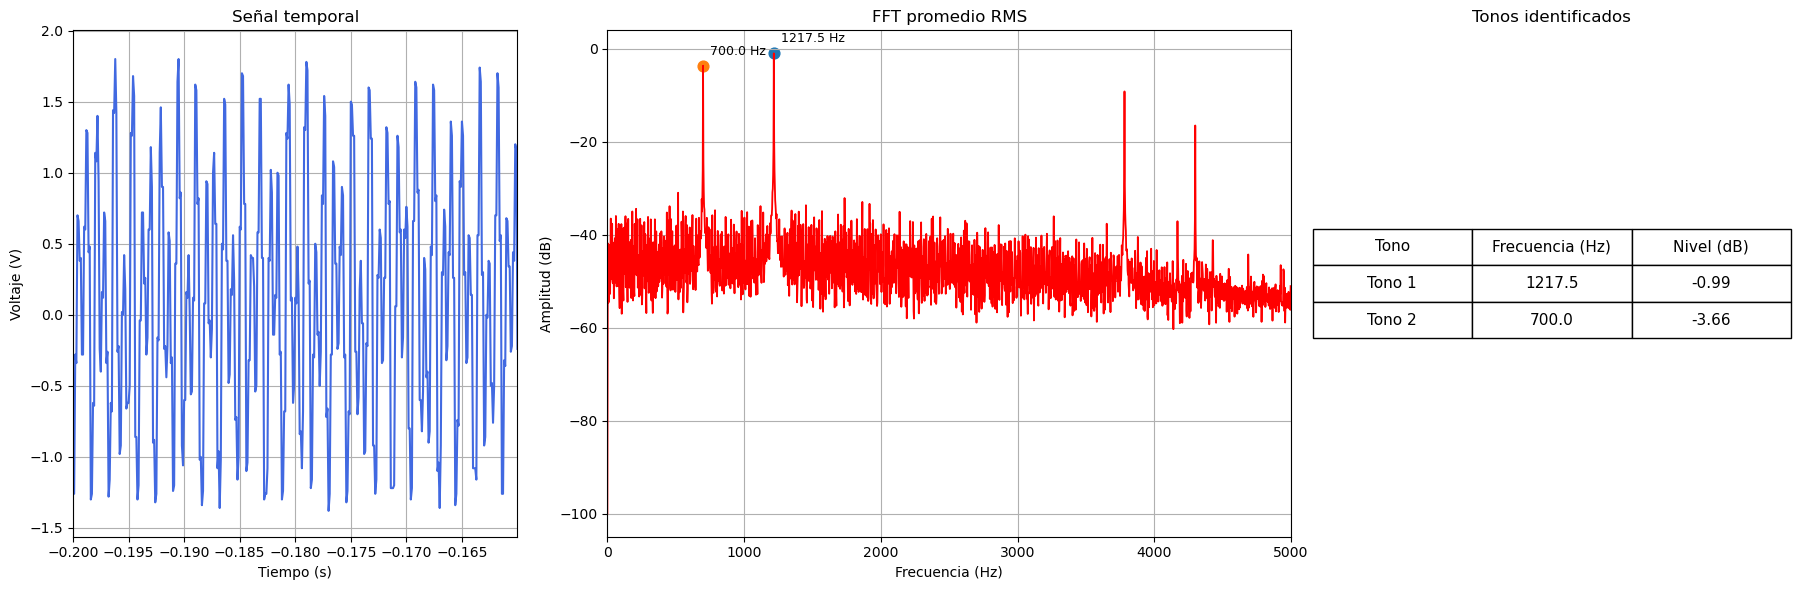

In [3]:
# ==========================
# Figura con 3 columnas
# ==========================
fig, axs = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'width_ratios': [1.3, 2, 1]}
)

# -------------------------------------------------
# Columna 1: Señal temporal (primer archivo)
# -------------------------------------------------
df = pd.read_csv(
    archivos[0],
    skiprows=16,
    names=['Tiempo', 'Voltaje'],
    index_col=False
)

tiempo = df['Tiempo'].to_numpy()
voltaje = df['Voltaje'].to_numpy()

axs[0].plot(tiempo, voltaje, color='royalblue')
axs[0].set_title("Señal temporal")
axs[0].set_xlabel("Tiempo (s)")
axs[0].set_ylabel("Voltaje (V)")

axs[0].set_xlim(tiempo[0], tiempo[0] + (tiempo[-1] - tiempo[0]) / 10)
axs[0].grid(True)

# -------------------------------------------------
# Columna 2: FFT promedio
# -------------------------------------------------
axs[1].plot(
    frecuencias_positivas,
    magnitud_db,
    color='red',
    linewidth=1.3
)

axs[1].set_title("FFT promedio RMS")
axs[1].set_xlabel("Frecuencia (Hz)")
axs[1].set_ylabel("Amplitud (dB)")
axs[1].set_xlim(0, 5000)
axs[1].grid(True)

# Marcar los dos picos
for i, indice in enumerate(top_2_picos):

    freq = frecuencias_positivas[indice]
    amp = magnitud_db[indice]

    axs[1].scatter(freq, amp, s=60)

    axs[1].annotate(
        f"{freq:.1f} Hz",
        (freq, amp),
        textcoords="offset points",
        xytext=(5,8),
        fontsize=9
    )

# -------------------------------------------------
# Columna 3: Tabla de tonos
# -------------------------------------------------
axs[2].axis('off')

tabla = []

for i, indice in enumerate(top_2_picos):

    tabla.append([
        f"Tono {i+1}",
        f"{frecuencias_positivas[indice]:.1f}",
        f"{magnitud_db[indice]:.2f}"
    ])

tabla = axs[2].table(
    cellText=tabla,
    colLabels=["Tono", "Frecuencia (Hz)", "Nivel (dB)"],
    loc='center',
    cellLoc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.4, 2)

axs[2].set_title("Tonos identificados")

plt.tight_layout()
plt.show()

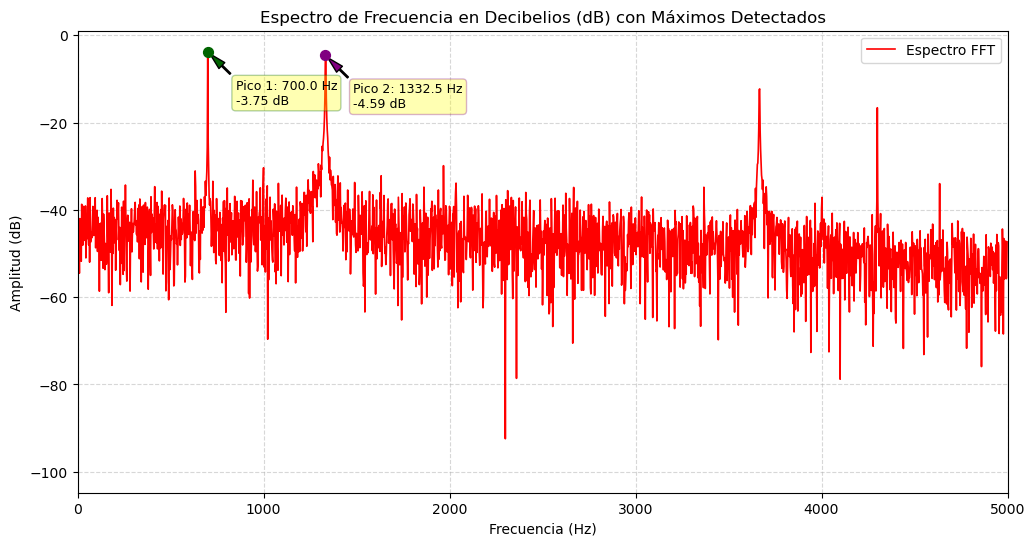

In [4]:
df = pd.read_csv(
    'medidas/DS0008.CSV', 
    skiprows=16, 
    names=['Tiempo', 'Voltaje'], 
    index_col=False
)

# 2. Parámetros de muestreo
dt = 1.00000e-04  # Período de muestreo (100 µs)
N = len(df)       # Cantidad de datos (4000 puntos)

# Extraer señal y quitar componente continua (DC) para no falsear los máximos
senal = df['Voltaje'].to_numpy()
senal_sin_dc = senal - np.mean(senal) 

# 3. Calcular la FFT
fft_valores = fft(senal_sin_dc)
frecuencias = fftfreq(N, dt)

# Mitad positiva
mitad = N // 2
frecuencias_positivas = frecuencias[:mitad]
magnitud_lineal = (2.0 / N) * np.abs(fft_valores[:mitad])

# 4. Convertir la amplitud a dB (con un piso de -100 dB para evitar errores de log(0))
magnitud_db = 20 * np.log10(np.clip(magnitud_lineal, 1e-5, None))

# 5. Encontrar los dos picos máximos
# 'distance=10' evita que el algoritmo elija muestras vecinas del mismo pico
picos_indices, _ = find_peaks(magnitud_db, distance=10)

# Ordenar los picos encontrados para quedarnos con los dos más altos
picos_ordenados = picos_indices[np.argsort(magnitud_db[picos_indices])][::-1]
top_2_picos = picos_ordenados[:2]

# 6. Graficar el espectro en dB
plt.figure(figsize=(12, 6))
plt.plot(frecuencias_positivas, magnitud_db, color='r', linewidth=1.2, label='Espectro FFT')

# 7. Marcar los dos máximos y colocar las etiquetas (labels)
colores_picos = ['darkgreen', 'purple']
for i, indice_pico in enumerate(top_2_picos):
    freq_pico = frecuencias_positivas[indice_pico]
    amp_db_pico = magnitud_db[indice_pico]
    
    # Dibujar un punto sobre el pico
    plt.scatter(freq_pico, amp_db_pico, color=colores_picos[i], s=50, zorder=5)
    
    # Crear el texto del label (Frecuencia y Amplitud en dB)
    label_texto = f"Pico {i+1}: {freq_pico:.1f} Hz\n{amp_db_pico:.2f} dB"
    
    # Anotación con flecha apuntando al pico
    plt.annotate(
        label_texto,
        xy=(freq_pico, amp_db_pico),
        xytext=(freq_pico + 150, amp_db_pico - 12),  # Desplazamiento del texto
        arrowprops=dict(facecolor=colores_picos[i], shrink=0.08, width=1, headwidth=6),
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3, ec=colores_picos[i]),
        fontsize=9
    )

# Personalización del gráfico
plt.title('Espectro de Frecuencia en Decibelios (dB) con Máximos Detectados')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (dB)')
plt.xlim(0, 5000)  # Límite de Nyquist para tus 10 kHz de muestreo
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()